Epoch 1 completed


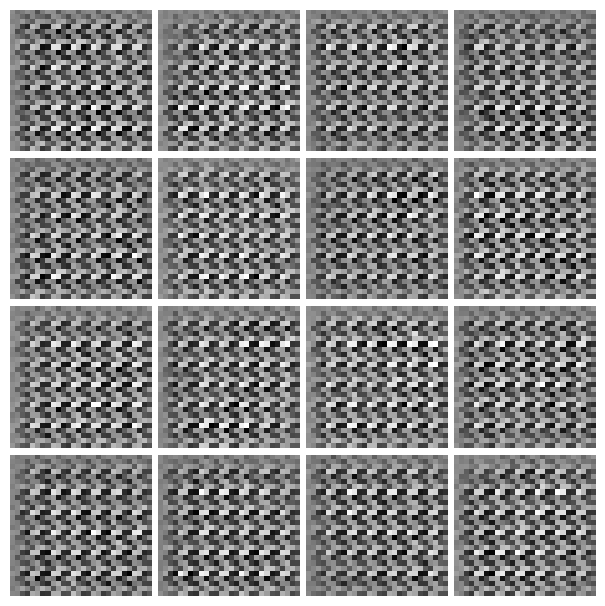

Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


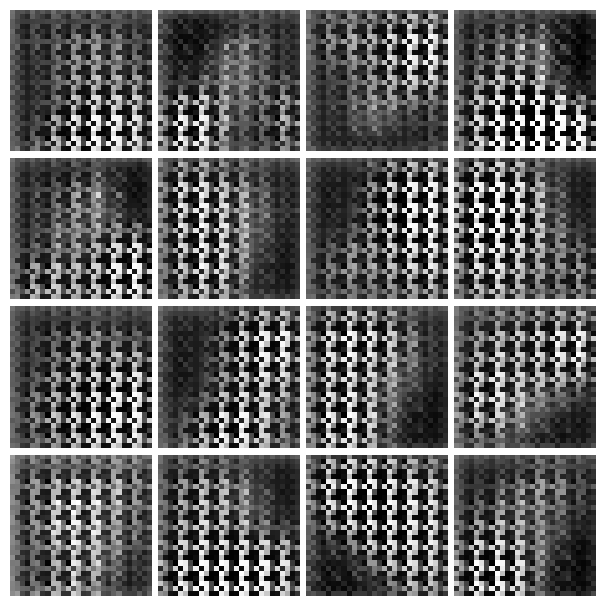

Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed


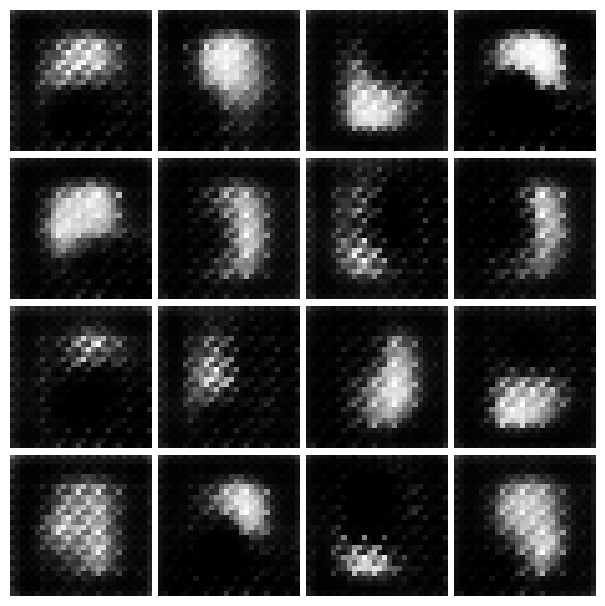

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# LOAD MNIST
# =========================
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Use only 5000 images for faster training
x_train = x_train[:10000]

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(5000).batch(256).prefetch(tf.data.AUTOTUNE)


# =========================
# GENERATOR
# =========================
generator = tf.keras.Sequential([
    tf.keras.Input(shape=(100,)),

    tf.keras.layers.Dense(7 * 7 * 128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 128)),

    tf.keras.layers.Conv2DTranspose(
        64, 5, strides=2, padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(
        1, 5, strides=2, padding="same",
        activation="tanh"
    )
])


# =========================
# DISCRIMINATOR
# =========================
discriminator = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(
        64, 5, strides=2, padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(
        128, 5, strides=2, padding="same"
    ),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# =========================
# LOSS + OPTIMIZERS
# =========================
loss_fn = tf.keras.losses.BinaryCrossentropy()

g_optimizer = tf.keras.optimizers.Adam(0.0002)
d_optimizer = tf.keras.optimizers.Adam(0.0002)


# =========================
# TRAINING STEP
# =========================
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [tf.shape(images)[0], 100]
    )

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:

        generated = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated,
            training=True
        )

        g_loss = loss_fn(
            tf.ones_like(fake_output),
            fake_output
        )

        d_loss_real = loss_fn(
            tf.ones_like(real_output),
            real_output
        )

        d_loss_fake = loss_fn(
            tf.zeros_like(fake_output),
            fake_output
        )

        d_loss = d_loss_real + d_loss_fake

    g_gradients = g_tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    d_gradients = d_tape.gradient(
        d_loss,
        discriminator.trainable_variables
    )

    g_optimizer.apply_gradients(
        zip(
            g_gradients,
            generator.trainable_variables
        )
    )

    d_optimizer.apply_gradients(
        zip(
            d_gradients,
            discriminator.trainable_variables
        )
    )


# =========================
# FIXED SEED
# =========================
seed = tf.random.normal([16, 100])


# =========================
# GENERATE 4x4 IMAGE GRID
# =========================
def generate_images(epoch):

    predictions = generator(
        seed,
        training=False
    )

    plt.figure(figsize=(6, 6))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.tight_layout(pad=0.5)

    os.makedirs("images", exist_ok=True)

    # Handles both numbers and "final"
    if isinstance(epoch, int):
        filename = f"images/image_at_epoch_{epoch:03d}.png"
    else:
        filename = f"images/image_at_epoch_{epoch}.png"

    plt.savefig(filename)

    plt.show()
    plt.close()


# =========================
# TRAIN
# =========================
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):

    for image_batch in dataset:
        train_step(image_batch)

    print("Epoch", epoch, "completed")

    # Generate output at epoch 1 and 5
    if epoch in [1, 5]:
        generate_images(epoch)


# =========================
# FINAL 4x4 OUTPUT
# =========================
generate_images("final")